## Test a New Strategy

In [3]:
%load_ext autoreload
%autoreload 2
import logging
from qrt.data import *
from qrt.utils import *
from qrt.constants import *
from qrt.qrt_utils import *
from qrt.strategies import *

logging.basicConfig(level=logging.WARNING, format='%(asctime)s | %(levelname)s | %(message)s', force=True)

In [2]:
update_price_data()

### Raw Data

In [4]:
historical_bb = pd.read_parquet(PRICE_DIR / BB_HISTORICAL)
active_lseg = pd.read_parquet(PRICE_DIR / LSEG_ACTIVE)

### Active Constituents Data

In [5]:
active_prices_rua, active_vol_rua = get_timeseries(active_lseg, stock_index=RUA), get_timeseries(active_lseg, value='Volume', stock_index=RUA)
active_eligible_rua = eligible_to_trade(active_prices_rua, active_vol_rua, stock_index=RUA)
active_returns_rua = active_prices_rua.ffill(limit=2).pct_change(fill_method=None).iloc[1:]

active_prices_stoxx, active_vol_stoxx = get_timeseries(active_lseg, stock_index=STOXX), get_timeseries(active_lseg, value='Volume', stock_index=STOXX)
active_eligible_stoxx = eligible_to_trade(active_prices_stoxx, active_vol_stoxx, stock_index=STOXX)
active_returns_stoxx = active_prices_stoxx.ffill(limit=2).pct_change(fill_method=None).iloc[1:]

### Historical Constituents Data

In [4]:
hist_prices_rua, hist_vol_rua = get_timeseries(historical_bb, stock_index=RUA, data_type='historical'), get_timeseries(historical_bb, value='Volume', stock_index=RUA, data_type='historical')
hist_eligible_rua = eligible_to_trade(hist_prices_rua, hist_vol_rua, stock_index=RUA)
hist_returns_rua = hist_prices_rua.ffill(limit=2).pct_change(fill_method=None).iloc[1:]

hist_prices_stoxx, hist_vol_stoxx = get_timeseries(historical_bb, stock_index=STOXX, data_type='historical'), get_timeseries(historical_bb, value='Volume', stock_index=STOXX, data_type='historical')
hist_eligible_stoxx = eligible_to_trade(hist_prices_stoxx, hist_vol_stoxx, stock_index=STOXX)
hist_returns_stoxx = hist_prices_stoxx.ffill(limit=2).pct_change(fill_method=None).iloc[1:]

KeyboardInterrupt: 

### Fundamental Data

In [6]:
active_sectors = get_data(active_lseg.RIC.unique().tolist(), ['TR.GICSSector'])
# historical_sectors = get_data(historical_bb.ISIN.unique().tolist(), ['TR.GICSSector'])

In [7]:
active_lseg_fund = pd.read_parquet(FUNDAMENTALS_DIR / LSEG_ACTIVE)
active_fundamentals = {}
for col in active_lseg_fund.columns[:-1]:
    key = col.lower().replace(' - actual', '').replace(' ', '_')
    pivoted = active_lseg_fund.pivot_table(index=active_lseg_fund.index, columns='RIC', values=col, observed=False)
    pivoted = pivoted.sort_index()
    active_fundamentals[key] = pivoted.ffill()

# historical_bb_fund = pd.read_parquet(FUNDAMENTALS_DIR / BB_HISTORICAL)
# historical_fundamentals = {}
# for col in historical_bb_fund.columns[:-1]:
#     key = col.lower().replace(' - actual', '').replace(' ', '_')
#     pivoted = historical_bb_fund.pivot_table(index=historical_bb_fund.index, columns='ISIN', values=col, observed=False)
#     pivoted = pivoted.sort_index()
#     historical_fundamentals[key] = pivoted.ffill()

### 1. Run strategies with active stock returns

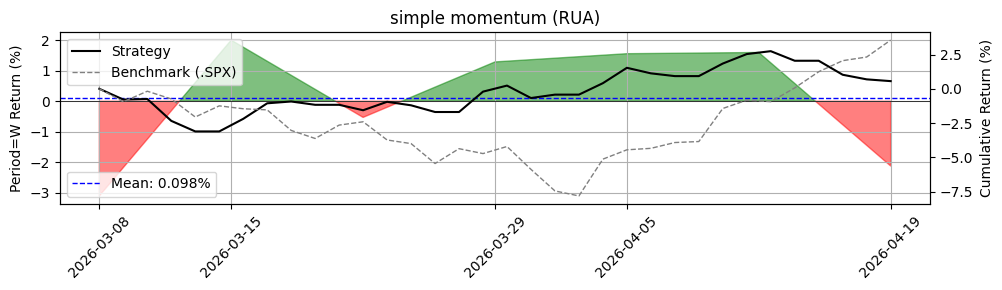

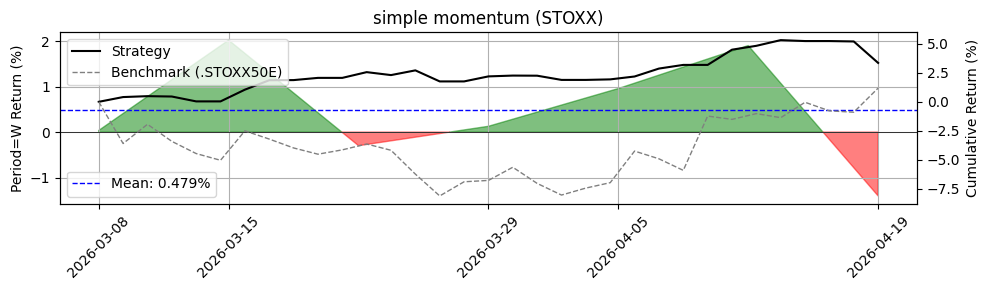

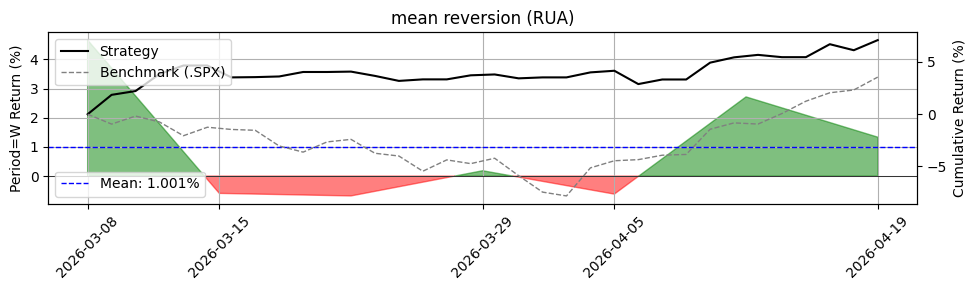

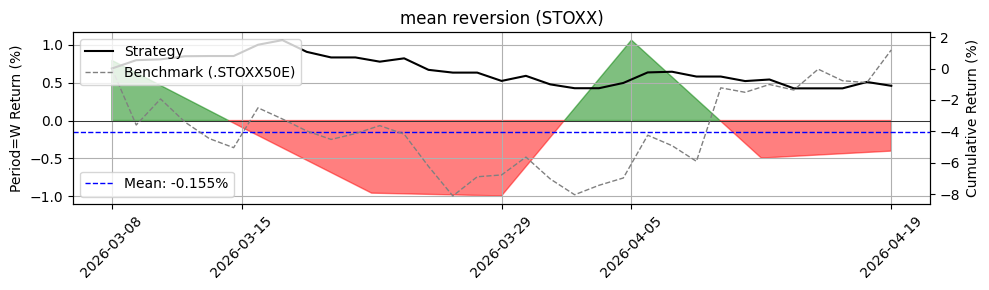

Running 3 reb_dates
Completed 3 all_weights


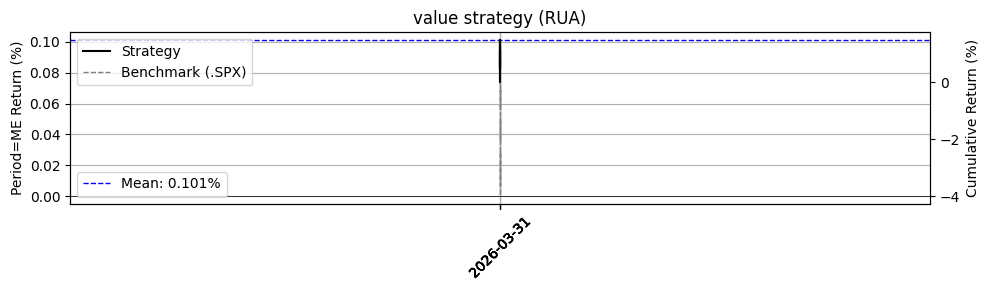

Running 3 reb_dates
Completed 3 all_weights


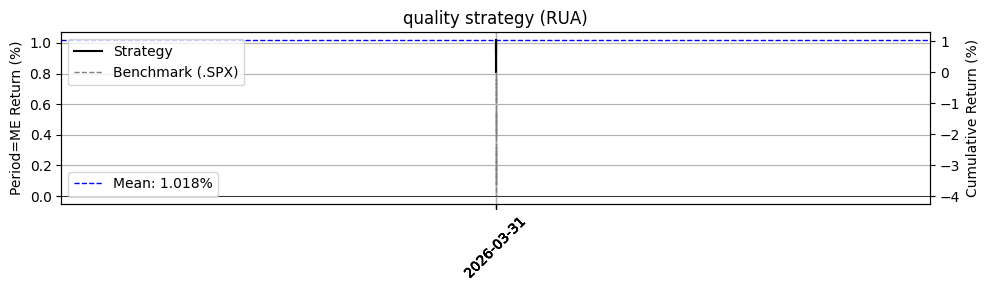

In [86]:
competition_start = '2026-03-01'

# # TIT MOM: RUA
# daily_ret, summary = backtest(
#     strategy_fn=titman_min_var_momentum,
#     return_data=active_returns_rua, 
#     volume_eligible=active_eligible_rua,
#     stock_index=RUA,
#     start_date=competition_start,
#     end_date=str(datetime.now().date()),
#     rebalance_freq=5,
#     # strategy_fn args:
#     lookback=252,
#     skip_last=21,
#     mom_quantile_top=0.8, 
#     mom_quantile_bottom=0.2, 
#     apply_screener=True, 
#     display_screener=False
# )
# # TIT MOM: STOXX
# daily_ret, summary = backtest(
#     strategy_fn=titman_min_var_momentum,
#     return_data=active_returns_stoxx, 
#     volume_eligible=active_eligible_stoxx,
#     stock_index=STOXX,
#     start_date=competition_start,
#     end_date=str(datetime.now().date()),
#     rebalance_freq=5,
#     # strategy_fn args:
#     lookback=252,
#     skip_last=21,
#     mom_quantile_top=0.8, 
#     mom_quantile_bottom=0.1, 
#     apply_screener=True, 
#     display_screener=False
# )

# SIM MOM: RUA
daily_ret, summary = backtest(
    strategy_fn=simple_momentum,
    return_data=active_returns_rua, 
    volume_eligible=active_eligible_rua,
    stock_index=RUA,
    start_date=competition_start,
    end_date=str(datetime.now().date()),
    rebalance_freq=5,
    # strategy_fn args:
    lookback=252, skip_last=10, quantile_top=0.8, quantile_bottom=0.2, vol_quantile=0.3
)
# SIM MOM: STOXX
daily_ret, summary = backtest(
    strategy_fn=simple_momentum,
    return_data=active_returns_stoxx, 
    volume_eligible=active_eligible_stoxx,
    stock_index=STOXX,
    start_date=competition_start,
    end_date=str(datetime.now().date()),
    rebalance_freq=5,
    # strategy_fn args:
    lookback=252, skip_last=10, quantile_top=0.8, quantile_bottom=0.2, vol_quantile=0.3
)

# MEAN REVERT: RUA
daily_ret, summary = backtest(
    strategy_fn=mean_reversion,
    return_data=active_returns_rua, 
    volume_eligible=active_eligible_rua,
    stock_index=RUA,
    start_date=competition_start,
    end_date=str(datetime.now().date()),
    rebalance_freq=5,
    # strategy_fn args:
    lookback=20,
    skip=5,
    quantile_top = 0.90,
    quantile_bottom = 0.10,
    vol_quantile = 0.95
)
# MEAN REVERT: STOXX
daily_ret, summary = backtest(
    strategy_fn=mean_reversion,
    return_data=active_returns_stoxx, 
    volume_eligible=active_eligible_stoxx,
    stock_index=STOXX,
    start_date=competition_start,
    end_date=str(datetime.now().date()),
    rebalance_freq=5,
    # strategy_fn args:
    lookback=5,
    skip=0,
    quantile_top = 0.90,
    quantile_bottom = 0.10,
    vol_quantile = 0.95
)

# VALUE: RUA
daily_ret, summary = backtest(
    strategy_fn=value_strategy,
    return_data=active_returns_rua, 
    volume_eligible=active_eligible_rua,
    stock_index=RUA,
    start_date=competition_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    resample='ME',
    # strategy_fn args:
    fundamentals=active_fundamentals
)

# QUALITY: RUA
daily_ret, summary = backtest(
    strategy_fn=quality_strategy,
    return_data=active_returns_rua, 
    volume_eligible=active_eligible_rua,
    stock_index=RUA,
    start_date=competition_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    resample='ME',
    # strategy_fn args:
    fundamentals=active_fundamentals
)


### 2. Backtest with historical returns

In [ ]:
hist_backtest_start = '2020-03-20'
# TIT MOM: RUA
daily_ret, summary = backtest(
    strategy_fn=titman_min_var_momentum,
    return_data=hist_returns_rua, 
    volume_eligible=hist_eligible_rua,
    stock_index=RUA,
    start_date=hist_backtest_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    parallel=True,
    # strategy_fn args:
    mom_quantile_top=0.8, mom_quantile_bottom=0.2,
)
# TIT MOM: STOXX
daily_ret, summary = backtest(
    strategy_fn=titman_min_var_momentum,
    return_data=hist_returns_stoxx, 
    volume_eligible=hist_eligible_stoxx,
    stock_index=STOXX,
    start_date=hist_backtest_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    parallel=True,
    # strategy_fn args:
    mom_quantile_top=0.8, mom_quantile_bottom=0.2,
)

# SIM MOM: RUA
daily_ret, summary = backtest(
    strategy_fn=simple_momentum,
    return_data=hist_returns_rua, 
    volume_eligible=hist_eligible_rua,
    stock_index=RUA,
    start_date=hist_backtest_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    resample='ME',
    # strategy_fn args:
)
# SIM MOM: STOXX
daily_ret, summary = backtest(
    strategy_fn=simple_momentum,
    return_data=hist_returns_stoxx, 
    volume_eligible=hist_eligible_stoxx,
    stock_index=STOXX,
    start_date=hist_backtest_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    resample='ME',
    # strategy_fn args:
)

# VALUE: RUA
daily_ret, summary = backtest(
    strategy_fn=value_strategy,
    return_data=hist_returns_rua, 
    volume_eligible=hist_eligible_rua,
    stock_index=RUA,
    start_date=hist_backtest_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    resample='ME',
    # strategy_fn args:
    fundamentals=historical_fundamentals
)
# VALUE: STOXX
daily_ret, summary = backtest(
    strategy_fn=value_strategy,
    return_data=hist_returns_stoxx, 
    volume_eligible=hist_eligible_stoxx,
    stock_index=STOXX,
    start_date=hist_backtest_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    resample='ME',
    # strategy_fn args:
    fundamentals=historical_fundamentals
)

# QUALITY: RUA
daily_ret, summary = backtest(
    strategy_fn=quality_strategy,
    return_data=hist_returns_rua, 
    volume_eligible=hist_eligible_rua,
    stock_index=RUA,
    start_date=hist_backtest_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    resample='ME',
    # strategy_fn args:
    fundamentals=historical_fundamentals
)
# QUALITY: STOXX
daily_ret, summary = backtest(
    strategy_fn=quality_strategy,
    return_data=hist_returns_stoxx, 
    volume_eligible=hist_eligible_stoxx,
    stock_index=STOXX,
    start_date=hist_backtest_start,
    end_date='2026-03-20',
    rebalance_freq=5,
    resample='ME',
    # strategy_fn args:
    fundamentals=historical_fundamentals
)


NameError: name 'hist_returns_rua' is not defined

### 3. Combine RUA & Stoxx porfolios, and scale risk to 500k USD

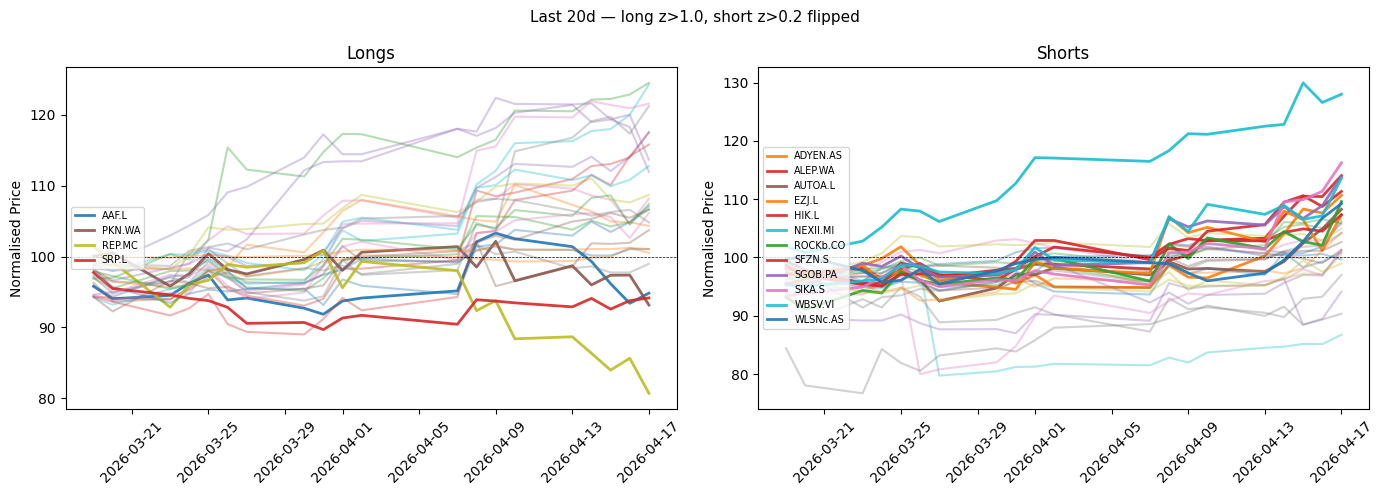

         RIC    weight   side  20d_return_pct  z_score     action
0   NEXII.MI -0.008850  short           28.00     2.86  flip sign
1     REP.MC  0.036721   long          -19.31     2.62  flip sign
2     PKN.WA  0.034809   long           -6.85     1.40  flip sign
3     SIKA.S -0.023286  short           16.23     1.38  flip sign
4      SRP.L  0.070000   long           -5.85     1.30  flip sign
5      AAF.L  0.011317   long           -5.17     1.24  flip sign
6    ALEP.WA -0.022189  short           14.05     1.11  flip sign
7    SGOB.PA -0.013589  short           13.87     1.08  flip sign
8    WBSV.VI -0.020710  short           13.59     1.05  flip sign
9     SFZN.S -0.014973  short           11.32     0.77  flip sign
10  ADYEN.AS -0.035559  short           10.65     0.68  flip sign
11  ROCKb.CO -0.040000  short            9.58     0.55  flip sign
12  WLSNc.AS -0.040000  short            9.25     0.51  flip sign
13   AUTOA.L -0.040000  short            8.25     0.38  flip sign
14     EZJ

Market Value           6,943,665
Combined Risk (USD)      500,000
AMER Risk                338,761
EMEA Risk                246,348
dtype: object

In [14]:
# weights_rua_mr, stats_rua_mr = mean_reversion(
#     active_returns_rua, active_eligible_rua, RUA, str(active_returns_rua.index[-1]),
#     lookback=21, skip=5, n_per_side=50
# )
# weights = combine_weights(
#     [weights_rua, weights_stoxx], [0.80, 0.20],
#     stock_index=RUA, target_beta=0.0
# )

weights_rua, stats_rua = titman_min_var_momentum(
    active_returns_rua, active_eligible_rua, RUA, str(active_returns_rua.index[-1]), active_sectors, active_fundamentals,
    mom_quantile_top=0.8, mom_quantile_bottom=0.2, display_screener=False, apply_screener=True, 
    screen_z_threshold_short=0.2, skip_last=1, sector_neutral=False, target_beta=-0.05
)

weights_stoxx, stats_stoxx = titman_min_var_momentum(
    active_returns_stoxx, active_eligible_stoxx, STOXX, str(active_returns_stoxx.index[-1]), active_sectors, active_fundamentals,
    mom_quantile_top=0.8, mom_quantile_bottom=0.2, display_screener=True, apply_screener=True, 
    screen_z_threshold_short=0.2, skip_last=1, sector_neutral=False, target_beta=-0.05
)

print(f"RUA MR longs: {(weights_rua > 0).sum()}, shorts: {(weights_rua < 0).sum()}")
print(f"RUA MOM longs: {(weights_stoxx > 0).sum()}, shorts: {(weights_stoxx < 0).sum()}")
scaled_positions = scale_portfolio_risk(
    weights_rua=weights_rua,
    weights_stoxx=weights_stoxx,
    target_risk_usd=500_000,
    display_stats=True
)

### 4. Plot Recent Performance & Submit Positions to QRT

In [15]:
print('beta:', portfolio_beta(weights_stoxx, STOXX))
print('beta:', portfolio_beta(weights_rua, RUA))
scaled_positions['target_notional'] = scaled_positions['target_notional']*-1

beta: 0.1911453133407879
beta: 0.4383782847319092


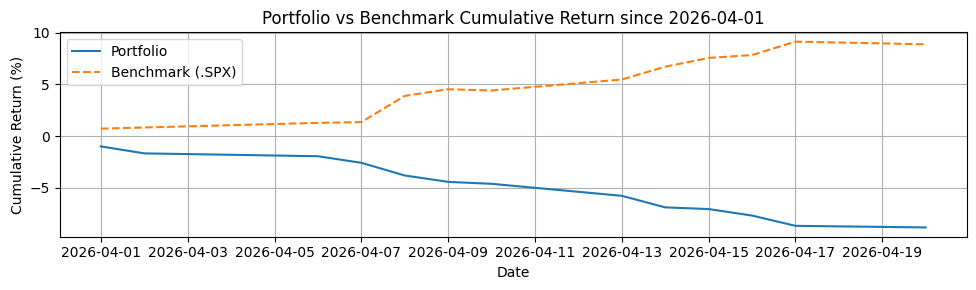

   internal_code  target_notional currency region  fx_rate  usd_notional
0         AAMI.N        -12584.59      USD   AMER      1.0      12584.59
1        ADMA.OQ         36804.41      USD   AMER      1.0     -36804.41
2           AI.N         47747.13      USD   AMER      1.0     -47747.13
3          ALK.N        -13365.27      USD   AMER      1.0      13365.27
4        APEI.OQ        -37615.54      USD   AMER      1.0      37615.54
..           ...              ...      ...    ...      ...           ...
82        VSCO.N        -78865.35      USD   AMER      1.0      78865.35
83        WBD.OQ        -30156.04      USD   AMER      1.0      30156.04
84        WDC.OQ        -34230.15      USD   AMER      1.0      34230.15
85         WHR.N         50163.17      USD   AMER      1.0     -50163.17
86         YOU.N        -47015.68      USD   AMER      1.0      47015.68

[87 rows x 6 columns]
Found 0 error(s) while validating /Users/dcunning/Code/Python/imperial/QRT/target_files/AMER/qrt_acad

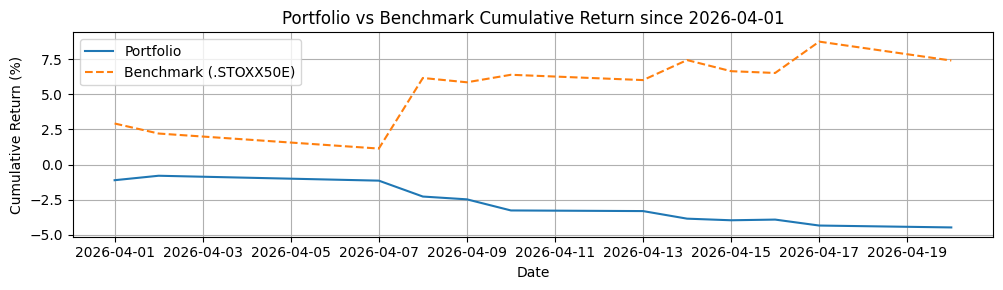

    internal_code  target_notional currency region   fx_rate  usd_notional
87          AAF.L         19150.43      GBp   EMEA  1.348436     -25823.13
88          ABF.L         67685.14      GBp   EMEA  1.348436     -91269.07
89       ADYEN.AS        -60170.38      EUR   EMEA  1.174122      70647.39
90         ALCC.S         59599.79      CHF   EMEA  1.276064     -76053.12
91        ALEP.WA        -37546.00      PLN   EMEA  0.277607      10423.02
92       ALLFG.AS        -77098.69      EUR   EMEA  1.174122      90523.29
93       AMBUb.CO         67685.19      DKK   EMEA  0.157101     -10633.38
94        AUTOA.L        -67685.16      GBp   EMEA  1.348436      91269.10
95         BALF.L        -66602.81      GBp   EMEA  1.348436      89809.62
96        BEIG.DE         67685.10      EUR   EMEA  1.174122     -79470.59
97         BGEO.L        -13697.50      GBp   EMEA  1.348436      18470.20
98         BTRW.L         46515.37      GBp   EMEA  1.348436     -62722.99
99       COLOb.CO        

In [17]:

for index in [RUA, STOXX]:
    pos_series = scaled_positions[scaled_positions.region==index.region].set_index('internal_code').target_notional
    if not pos_series.empty:
        plot_portfolio_returns(pos_series, index, start_date='2026-04-01')
        new_positions = scaled_positions[scaled_positions.region == index.region]
    else:
        new_positions = pd.DataFrame(
            {'internal_code': '.STOXX50E', 'target_notional': 1.0, 'currency': 'EUR', 'region': 'EMEA', 'fx_rate': 1.0, 'usd_notional': 1.0}, index=[0]
        )
    print(new_positions)
    send_new_portfolio(
        targets=new_positions,
        region=index.region,
        submit=False
    )
    print('beta:', portfolio_beta(pos_series, index))


# positions = most_recent_positions(stock_index=RUA)
# plot_portfolio_returns(positions, stock_index=RUA)
# positions = most_recent_positions(stock_index=STOXX)
# plot_portfolio_returns(positions, stock_index=STOXX)

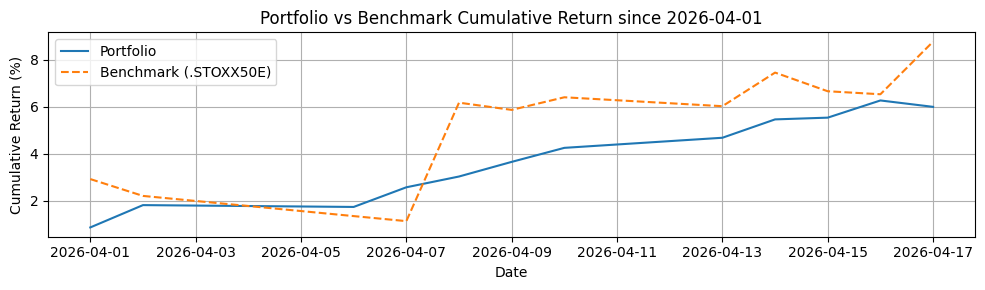

In [62]:
df = pd.read_excel(TARGETS_DIR / "QRT" / "QSec_Detailed_ICL05_2026-04-16.xlsx", index_col=0)
qrt_positions = df[[
    "Instrument", "New RIC", "Book ID",
    "Position EOD USD", "Position EOD Shares", "EOD Price",
    "Beta", "Target USD", "Day PnL USD",
]].copy()
qrt_positions = (
    df.loc[df["Book ID"]=="ICL05_AMER"]
      .set_index("Instrument")["Position EOD USD"]
      .rename_axis("ric")
      .sort_index()
)

# scaled_positions.set_index('internal_code')['target_notional']
sent_positions = most_recent_positions(stock_index=RUA, date='2026-04-17')

# plot_portfolio_returns(scaled_positions.set_index('internal_code')['target_notional'], stock_index=STOXX, start_date='2026-04-01')
plot_portfolio_returns(weights_rua, stock_index=STOXX, start_date='2026-04-01')

### Factor Portfolio Optimisation

- Combine different strategies: mom, value, quality
- See which strategies/region combinations are currently best performing
- Determine current market inovations which would suggest changing strategy weights

## Instructions

### Hedging
To hedge excessive residual beta in your equity portfolio:
1.	Compute the beta of each stock using a 250-day covariance with its benchmark:
$$\text{Beta} = 0.2 + 0.8 \times \frac{\text{Cov}_{250d}(\text{stock}, \text{benchmark})}{\text{Var}_{250d}(\text{benchmark})}$$
2. Hedge the beta exposure by taking a position in the benchmark equal to:
$$\text{Hedge Position} = -\text{Beta}$$
3. Benchmarks:
  - AMER: S&P 500 (SPX)
  - EMEA: Eurostoxx50

This means that if a stock has a beta of 1.2, you would short 1.2 units of the benchmark to neutralize the market exposure.

### Trading Limits
There are some trading limits for single stocks: 
- Max position = 2.5% of the 60 trading days ADV 
- Max traded per day = 2.5% of the 60 trading days ADV 

For single stocks, there is also a max position in term of USD: 
- Max position = 2 M USD 

If the implied trading by targets exceeds the above limits, the position will be kept constant until all limits are not exceeded anymore. 

### Trading Costs
The execution price will be the mid-price at the end of the next minute after we have received your file (without format error) on the ftp. Additional execution costs of 2bps also apply, along with 0.5% (annually) for financing. 

100% of dividends are paid on short positions. 70% of dividends are received on long positions. 

### Ex-Ante Portfolio Risk

Risk Formula
$$
\text{Risk}_t = \sqrt{ x_t^\top \, \Sigma_t \, x_t }
$$

Where:
- $x_t$ = portfolio weights at time $t$
- $\Sigma_t$ = covariance matrix of asset returns  

Computation Steps
1. Select last 60 daily returns.  
2. Compute daily P&L:

$$
\text{PnL}_t = \text{positions}_{t-1} \cdot \text{return}_t
$$

3. Compute standard deviation of P&L.  
4. Annualise: multiply by $\sqrt{252}$.  

Simulation Parameters
- Asset class: Equities  
- Regions: AMER, EMEA  
- Universe: Russell 3000, Stoxx 600  
- Trading hours: Standard per region  
- Execution cost: 2 bps  
- Financing cost: 0.5% GMV  
- Dividend tax: 30%  
- Spread cost: 0  
- Max traded/day: 2.5% ADV  
- Position limit: 2.5% ADV  
- Auto-hedging: TRUE  
- Risk limit: 500k USD (annualised)